# 🏺 Tourasna — Glyph Classification (Stage 2)
# EfficientNetB0 → Gardiner Code Classification
# Dataset: GlyphReader (Franken et al.)
# Repo: github.com/Tourasna/Tourasna

In [2]:
# ── Cell 2: Download GlyphReader dataset ──────────────
!git clone https://github.com/morrisfranken/glyphreader.git /content/glyphreader

Cloning into '/content/glyphreader'...
remote: Enumerating objects: 55, done.
remote: Total 55 (delta 0), reused 0 (delta 0), pack-reused 55 (from 1)
Receiving objects: 100% (55/55), 5.06 MiB | 11.58 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [3]:
# ── Cell 3: Trigger dataset download ─────────────────
%cd /content/glyphreader
!python3 -c "from src.data import fetch; fetch.download_data()"

/content/glyphreader
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'src.data'


In [4]:
# ── Cell 4: Check what we got ─────────────────────────
!find /content/glyphreader -type f -name "*.png" | head -5
!echo "---"
!find /content/glyphreader -type f -name "*.png" | wc -l

/content/glyphreader/examples/200006_X1.png
/content/glyphreader/examples/200002_V13.png
/content/glyphreader/examples/200009_S29.png
/content/glyphreader/examples/200001_V13.png
/content/glyphreader/examples/200004_D21.png
---
18


In [5]:
# ── Cell 5: Download the actual dataset ───────────────
%cd /content
!wget -q --show-progress "http://iamai.nl/downloads/GlyphDataset.zip" -O GlyphDataset.zip
!unzip -q GlyphDataset.zip -d /content/glyphreader_data
!ls /content/glyphreader_data

/content
[GlyphDataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of GlyphDataset.zip or
        GlyphDataset.zip.zip, and cannot find GlyphDataset.zip.ZIP, period.
ls: cannot access '/content/glyphreader_data': No such file or directory


In [6]:
# ── Cell 6: Try tar.gz format ─────────────────────────
%cd /content
!rm -f GlyphDataset.zip
!wget -q --show-progress "http://iamai.nl/downloads/GlyphDataset.tar.gz" -O GlyphDataset.tar.gz
!ls -lh GlyphDataset.tar.gz

/content
-rw-r--r-- 1 root root 0 Apr 10 22:16 GlyphDataset.tar.gz


In [7]:
# ── Cell 7: Search for hieroglyph datasets on Kaggle ──
!pip install kaggle -q

# Upload your kaggle.json
from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Search
!kaggle datasets list -s "hieroglyph" --csv

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
ref,title,size,lastUpdated,downloadCount,voteCount,usabilityRating
alexandrepetit881234/egyptian-hieroglyphs,Egyptian Hieroglyphs,10871531,2023-08-05 12:07:15.377000,3956,24,0.9411765
waleedumer/egyptian-hieroglyphics-datasets,Egyptian Hieroglyphics Datasets,17157912,2021-10-01 17:42:27.110000,1046,40,0.6875
ahmedsamir1598/glyphdataset,Egyptian Hieroglyphs: GlyphDataset,58289435,2024-09-10 08:24:32.213000,153,7,1
ayatollahelkolally/hieroglyphs-dataset,Hieroglyphs_Dataset,11498608,2024-12-28 00:25:51.807000,182,3,0.6875
ahmedelkelany/egyptian-hieroglyphic-layout-analysis,Egyptian Hieroglyphic Layout Analysis,3101769526,2025-06-13 21:29:07.760000,59,5,0.875
mdismielhossenabir/hieroglyphs-handwriting-letter-recognition,Hieroglyphs Handwriting Alphabet Recognition,658220,2024-07-08 18:10:46.517000,53,7,0.8125
ahmedelkelany/egyptian-hieroglyphic-signs-segmentation,Egyptian Hieroglyphic Signs Segmentation,48685747,2025-06-13 20:21:54.623000,78,3,0.875
mohiey

In [8]:
# ── Cell 8: Download GlyphDataset ─────────────────────
!kaggle datasets download -d ahmedsamir1598/glyphdataset -p /content/glyphdata --unzip -q

# Check structure
!ls /content/glyphdata
!find /content/glyphdata -name "*.png" | wc -l
!find /content/glyphdata -name "*.png" | head -10

Dataset URL: https://www.kaggle.com/datasets/ahmedsamir1598/glyphdataset
License(s): other
Dataset
17378
/content/glyphdata/Dataset/Manual/Preprocessed/5/050116_Q1.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050306_D21.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050123_D60.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050087_W11.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050425_N35.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050126_UNKNOWN.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050234_S29.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050433_I9.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050374_U15.png
/content/glyphdata/Dataset/Manual/Preprocessed/5/050130_S29.png


In [9]:
# ── Cell 9: Analyze dataset structure ─────────────────
import glob, os, re
from collections import Counter

# Find all images
all_images = glob.glob('/content/glyphdata/**/*.png', recursive=True)

# Extract Gardiner code from filename
# Pattern: "050116_Q1.png" → "Q1"
def extract_gardiner(filepath):
    name = os.path.basename(filepath).replace('.png', '')
    parts = name.split('_')
    if len(parts) >= 2:
        return parts[-1]  # Last part = Gardiner code
    return 'UNKNOWN'

labels = [extract_gardiner(f) for f in all_images]
counts = Counter(labels)

print(f"Total images:   {len(all_images)}")
print(f"Unique classes: {len(counts)}")
print(f"UNKNOWN count:  {counts.get('UNKNOWN', 0)}")
print(f"\nTop 30 classes:")
for label, count in counts.most_common(30):
    print(f"  {label:10s} → {count:4d} images")

print(f"\nBottom 10 classes (least samples):")
for label, count in counts.most_common()[-10:]:
    print(f"  {label:10s} → {count:4d} images")

Total images:   17378
Unique classes: 172
UNKNOWN count:  2776

Top 30 classes:
  UNKNOWN    → 2776 images
  N35        → 1472 images
  M17        → 1342 images
  S29        → 1010 images
  X1         →  890 images
  G43        →  766 images
  G17        →  728 images
  D21        →  606 images
  I9         →  492 images
  V31        →  480 images
  E34        →  446 images
  O50        →  406 images
  Q3         →  290 images
  V13        →  278 images
  D36        →  206 images
  R8         →  202 images
  D35        →  194 images
  Z1         →  182 images
  D46        →  174 images
  W24        →  152 images
  G35        →  150 images
  D58        →  140 images
  D4         →  138 images
  M23        →  138 images
  I10        →  136 images
  V28        →  136 images
  G1         →  136 images
  G5         →  116 images
  N37        →  114 images
  G25        →   96 images

Bottom 10 classes (least samples):
  D62        →    4 images
  M26        →    4 images
  D34        →    4 

Threshold ≥  2: 171 classes, 14602 images
Threshold ≥  5: 134 classes, 14466 images
Threshold ≥ 10: 117 classes, 14340 images
Threshold ≥ 20:  81 classes, 13868 images


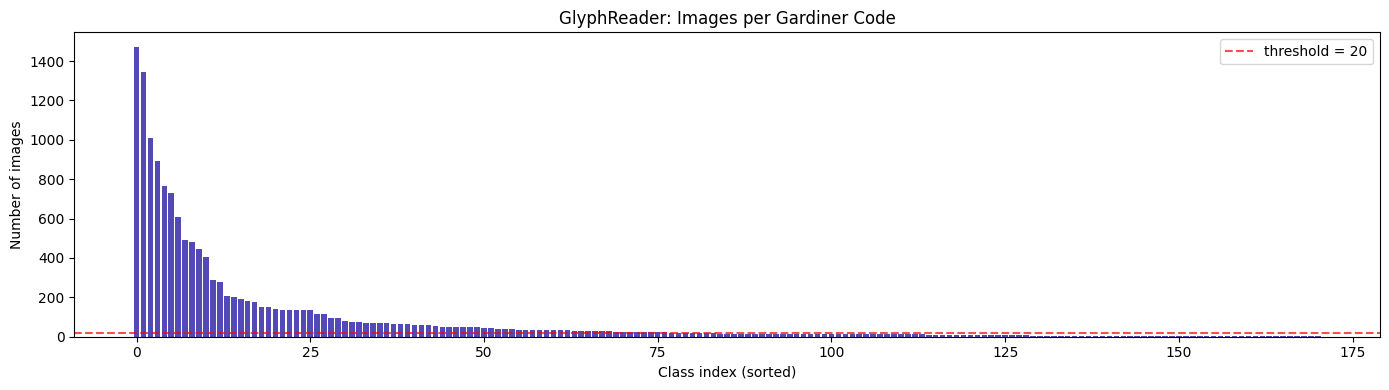

In [10]:
# ── Cell 10: Distribution analysis + filtering decision ─
import matplotlib.pyplot as plt

# Remove UNKNOWN
filtered_counts = {k: v for k, v in counts.items() if k != 'UNKNOWN'}

# Sort by count
sorted_counts = sorted(filtered_counts.values(), reverse=True)

# Show thresholds
for threshold in [2, 5, 10, 20]:
    valid = sum(1 for c in filtered_counts.values() if c >= threshold)
    images = sum(c for c in filtered_counts.values() if c >= threshold)
    print(f"Threshold ≥ {threshold:2d}: {valid:3d} classes, {images:5d} images")

# Plot distribution
plt.figure(figsize=(14, 4))
plt.bar(range(len(sorted_counts)), sorted_counts, color='#534AB7')
plt.xlabel('Class index (sorted)')
plt.ylabel('Number of images')
plt.title('GlyphReader: Images per Gardiner Code')
plt.axhline(y=20, color='red', linestyle='--', alpha=0.7, label='threshold = 20')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ── Cell 11: Build clean dataset ──────────────────────
import numpy as np
from sklearn.model_selection import train_test_split

MIN_SAMPLES = 10

# Filter: remove UNKNOWN + classes with < MIN_SAMPLES
valid_classes = {k for k, v in counts.items()
                 if k != 'UNKNOWN' and v >= MIN_SAMPLES}

# Build parallel lists
clean_images = []
clean_labels = []
for img, label in zip(all_images, labels):
    if label in valid_classes:
        clean_images.append(img)
        clean_labels.append(label)

# Create class-to-index mapping (sorted for reproducibility)
class_names = sorted(valid_classes)
class_to_idx = {name: i for i, name in enumerate(class_names)}

print(f"Clean dataset: {len(clean_images)} images, {len(class_names)} classes")
print(f"Removed: {len(all_images) - len(clean_images)} images")
print(f"\nFirst 10 classes: {class_names[:10]}")
print(f"Last 10 classes:  {class_names[-10:]}")

# Train/Val/Test split (70/15/15)
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    clean_images, clean_labels,
    test_size=0.3, random_state=42, stratify=clean_labels
)
val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs, temp_lbls,
    test_size=0.5, random_state=42, stratify=temp_lbls
)

print(f"\nSplit:")
print(f"  Train: {len(train_imgs)}")
print(f"  Val:   {len(val_imgs)}")
print(f"  Test:  {len(test_imgs)}")

Clean dataset: 14340 images, 117 classes
Removed: 3038 images

First 10 classes: ['Aa26', 'Aa27', 'D1', 'D156', 'D19', 'D2', 'D21', 'D28', 'D35', 'D36']
Last 10 classes:  ['W24', 'W25', 'X1', 'X8', 'Y2', 'Y3', 'Y5', 'Z1', 'Z11', 'Z7']

Split:
  Train: 10038
  Val:   2151
  Test:  2151


Train batches: 314
Val batches:   68
Test batches:  68


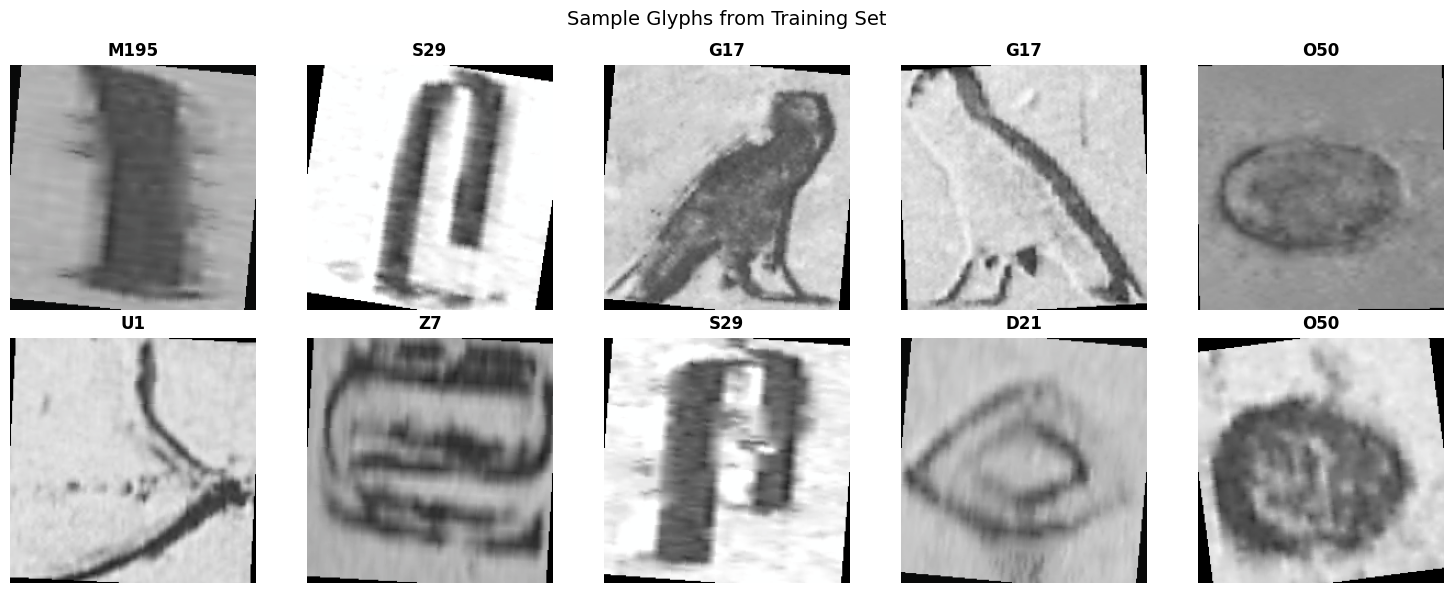

In [12]:
# ── Cell 12: PyTorch Dataset & DataLoaders ────────────
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ── Custom Dataset ────────────────────────────────────
class GlyphDataset(Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = [class_to_idx[l] for l in labels]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# ── Transforms ────────────────────────────────────────
# EfficientNetB0 expects 224x224, ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Create datasets & loaders ─────────────────────────
train_dataset = GlyphDataset(train_imgs, train_lbls, class_to_idx, train_transform)
val_dataset   = GlyphDataset(val_imgs, val_lbls, class_to_idx, val_transform)
test_dataset  = GlyphDataset(test_imgs, test_lbls, class_to_idx, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# ── Visualize a few samples ───────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
idx_to_class = {v: k for k, v in class_to_idx.items()}

for i, (img, label) in enumerate(train_dataset):
    if i >= 10:
        break
    ax = axes[i // 5][i % 5]
    # Denormalize for display
    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = img_np.clip(0, 1)
    ax.imshow(img_np)
    ax.set_title(idx_to_class[label], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Glyphs from Training Set', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# ── Cell 13: Build EfficientNetB0 Classifier ──────────
import torch.nn as nn
from torchvision import models

NUM_CLASSES = len(class_names)  # 117

# Load pretrained EfficientNetB0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze early layers, train later layers + classifier
# EfficientNet structure: features (convs) → classifier
for param in model.features[:5].parameters():  # freeze first 5 blocks
    param.requires_grad = False

# Replace classifier head
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Count parameters
total    = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device:     {device}")
print(f"Classes:    {NUM_CLASSES}")
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 40.7MB/s]


Device:     cuda
Classes:    117
Total params:     4,157,425
Trainable params: 3,848,765 (92.6%)


In [15]:
# ── Cell 14: Training Loop ────────────────────────────
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

# ── Config ────────────────────────────────────────────
EPOCHS = 30
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

# ── Training function ─────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

# ── Train ─────────────────────────────────────────────
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} {'Train Acc':>10} | {'Val Loss':>10} {'Val Acc':>10} | {'Time':>6}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start

    print(f"{epoch:5d} | {train_loss:10.4f} {train_acc:10.4f} | {val_loss:10.4f} {val_acc:10.4f} | {elapsed:5.1f}s")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_classifier.pth')
        print(f"        ↑ New best! Val Acc: {val_acc:.4f}")

print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.4f}")

Epoch | Train Loss  Train Acc |   Val Loss    Val Acc |   Time
----------------------------------------------------------------------
    1 |     1.1287     0.7362 |     0.3834     0.8917 |  45.2s
        ↑ New best! Val Acc: 0.8917
    2 |     0.3537     0.8981 |     0.2211     0.9368 |  45.3s
        ↑ New best! Val Acc: 0.9368
    3 |     0.2429     0.9284 |     0.2151     0.9382 |  44.8s
        ↑ New best! Val Acc: 0.9382
    4 |     0.1884     0.9447 |     0.1955     0.9498 |  43.5s
        ↑ New best! Val Acc: 0.9498
    5 |     0.1664     0.9490 |     0.1755     0.9484 |  42.8s
    6 |     0.1402     0.9569 |     0.1600     0.9614 |  44.7s
        ↑ New best! Val Acc: 0.9614
    7 |     0.1262     0.9616 |     0.1818     0.9558 |  43.0s
    8 |     0.1110     0.9658 |     0.1425     0.9586 |  44.6s
    9 |     0.1041     0.9669 |     0.1620     0.9637 |  44.0s
        ↑ New best! Val Acc: 0.9637
   10 |     0.0901     0.9720 |     0.1719     0.9591 |  43.4s
   11 |     0.0895  

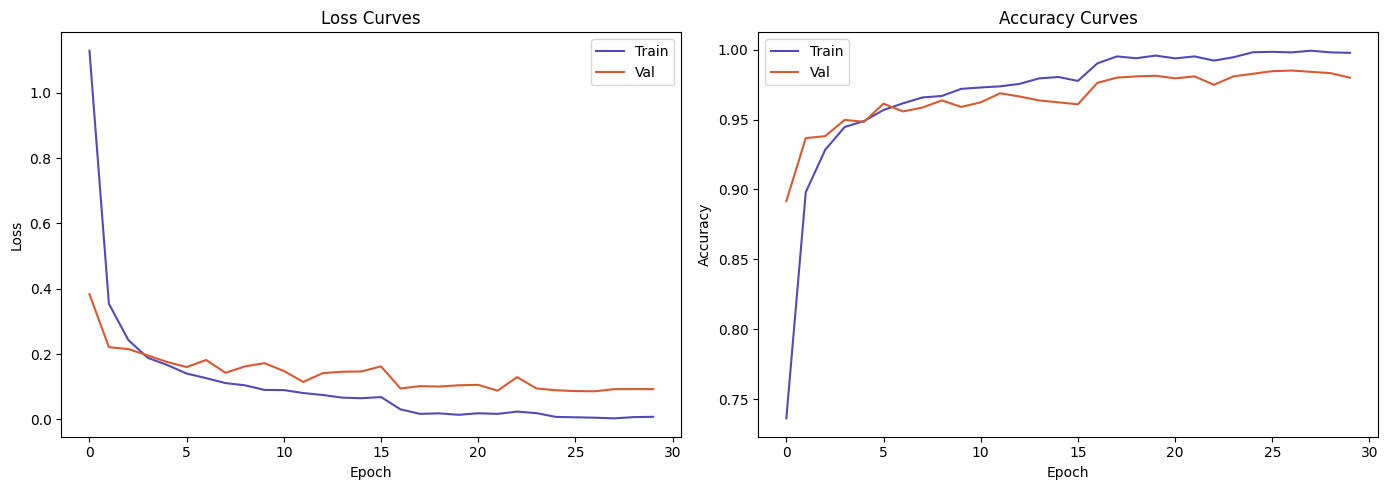


🎯 Test Set Results:
   Loss:     0.0742
   Accuracy: 0.9842 (98.42%)


In [16]:
# ── Cell 15: Evaluation + Training Curves ─────────────
import matplotlib.pyplot as plt

# ── Plot training curves ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train', color='#534AB7')
ax1.plot(history['val_loss'], label='Val', color='#D85A30')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(history['train_acc'], label='Train', color='#534AB7')
ax2.plot(history['val_acc'], label='Val', color='#D85A30')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()

plt.tight_layout()
plt.show()

# ── Test set evaluation ───────────────────────────────
model.load_state_dict(torch.load('/content/best_classifier.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\n🎯 Test Set Results:")
print(f"   Loss:     {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

In [17]:
# ── Cell 16: Classification Report + Save ─────────────
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import json

# ── Get all predictions ───────────────────────────────
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# ── Top misclassified classes ─────────────────────────
errors = all_preds != all_true
error_classes = [class_names[t] for t, e in zip(all_true, errors) if e]
from collections import Counter
error_counts = Counter(error_classes)

print("❌ Most confused classes:")
for cls, count in error_counts.most_common(10):
    total_in_class = sum(1 for t in all_true if class_names[t] == cls)
    print(f"  {cls:8s} → {count}/{total_in_class} wrong ({100*count/total_in_class:.1f}%)")

# ── Save model + metadata ─────────────────────────────
# Save class mapping
metadata = {
    'class_names': class_names,
    'class_to_idx': class_to_idx,
    'num_classes': NUM_CLASSES,
    'test_accuracy': float(test_acc),
    'best_val_accuracy': float(best_val_acc),
    'model': 'EfficientNetB0',
    'dataset': 'GlyphReader (ahmedsamir1598/glyphdataset)',
    'min_samples_threshold': MIN_SAMPLES,
}

with open('/content/classifier_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✅ Saved:")
print(f"   Model:    /content/best_classifier.pth")
print(f"   Metadata: /content/classifier_metadata.json")

# ── Copy to Google Drive ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
save_dir = '/content/drive/MyDrive/Tourasna/hieroglyphics/classifier'
os.makedirs(save_dir, exist_ok=True)

shutil.copy('/content/best_classifier.pth', f'{save_dir}/best_classifier.pth')
shutil.copy('/content/classifier_metadata.json', f'{save_dir}/classifier_metadata.json')

print(f"   Backed up to Google Drive ✅")

❌ Most confused classes:
  O50      → 6/61 wrong (9.8%)
  M17      → 2/201 wrong (1.0%)
  V13      → 2/41 wrong (4.9%)
  N17      → 2/5 wrong (40.0%)
  R8       → 2/30 wrong (6.7%)
  O4       → 2/7 wrong (28.6%)
  G17      → 2/109 wrong (1.8%)
  G43      → 2/115 wrong (1.7%)
  M3       → 1/2 wrong (50.0%)
  G1       → 1/20 wrong (5.0%)

✅ Saved:
   Model:    /content/best_classifier.pth
   Metadata: /content/classifier_metadata.json
Mounted at /content/drive
   Backed up to Google Drive ✅
